In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

PROJECT_PATH = "/content/drive/MyDrive/ecommerce-product-recommendation-knn"

folders = [
    "data",
    "models",
    "outputs",
    "outputs/charts"
]

for folder in folders:
    os.makedirs(os.path.join(PROJECT_PATH, folder), exist_ok=True)

print("Project folders created.")

Project folders created.


In [4]:
import os

# List the contents of the data folder
print(os.listdir(os.path.join(PROJECT_PATH, "data")))


['ecommerce_mock_dataset.csv']


In [6]:
import pandas as pd

# DATA_PATH is already defined in the kernel context
# DATA_PATH = os.path.join(PROJECT_PATH,"data","ecommerce_mock_dataset.csv")

df = pd.read_csv(DATA_PATH)

display(df.head())

,Customer_ID,Product_ID,Product_Category,Purchase_History,Rating,Browsing_Behaviour,Transaction_Date
0,C001,P801,Accessories,Yes,4.5,Purchased,2025-01-27
1,C001,P102,Electronics,Yes,3.6,Wishlist,2025-01-27
2,C001,P105,Electronics,Yes,3.5,Frequently Viewed,2025-01-27
3,C001,P503,Home,Yes,4.6,Wishlist,2025-06-16
4,C001,P701,Books,Yes,4.2,Frequently Viewed,2025-06-16


In [7]:
df = df.drop_duplicates()

df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

df["Browsing_Behaviour"] = df["Browsing_Behaviour"].str.strip()

df["Product_Category"] = df["Product_Category"].str.title()

df = df.dropna()

clean_path = os.path.join(PROJECT_PATH,"data","ecommerce_cleaned.csv")

df.to_csv(clean_path,index=False)

print(df.shape)

(250, 7)


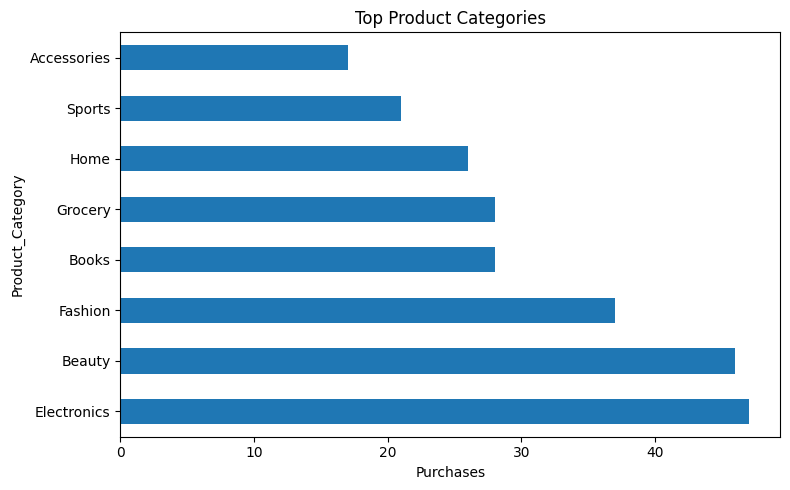

In [8]:
import matplotlib.pyplot as plt

category_counts = df["Product_Category"].value_counts()

plt.figure(figsize=(8,5))
category_counts.plot(kind="barh")
plt.title("Top Product Categories")
plt.xlabel("Purchases")

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_PATH,"outputs/charts/top_categories.png"))

plt.show()

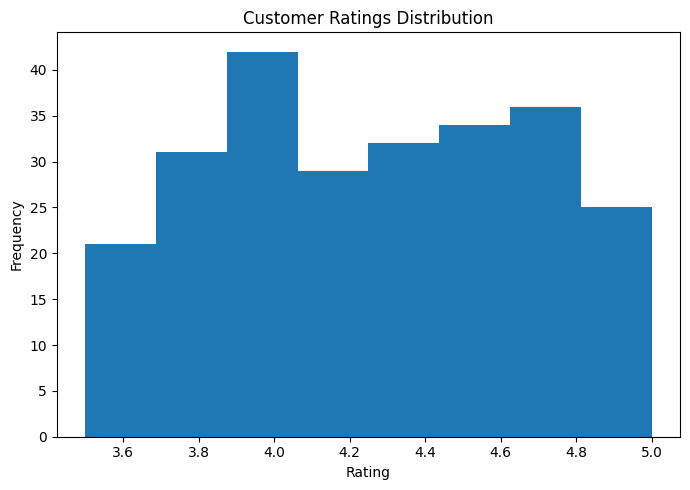

In [9]:
plt.figure(figsize=(7,5))

plt.hist(df["Rating"], bins=8)

plt.title("Customer Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_PATH,"outputs/charts/rating_distribution.png"))

plt.show()

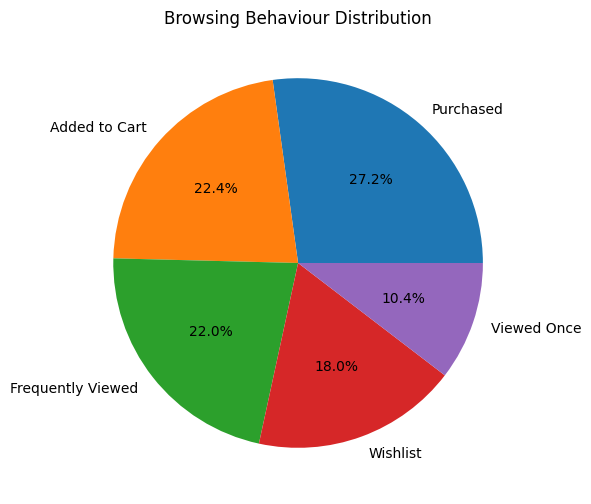

In [10]:
behaviour = df["Browsing_Behaviour"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    behaviour,
    labels=behaviour.index,
    autopct="%1.1f%%"
)

plt.title("Browsing Behaviour Distribution")

plt.savefig(os.path.join(PROJECT_PATH,"outputs/charts/browsing_behaviour.png"))

plt.show()

In [11]:
!pip install mlxtend

In [12]:
basket = (
    df.groupby(["Customer_ID","Product_ID"])["Purchase_History"]
      .count()
      .unstack(fill_value=0)
)

basket = basket.applymap(lambda x: 1 if x>0 else 0)

basket.head()

/tmp/ipykernel_933/169215214.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x>0 else 0)


Product_ID,P101,P102,P103,P104,P105,P106,P201,P202,P203,P204,...,P401,P402,P502,P503,P601,P602,P701,P702,P801,P802
Customer_ID,,,,,,,,,,,,,,,,,,,,,
C001,0,1,0,0,1,0,0,0,0,0,...,1,1,0,1,0,0,1,0,1,0
C002,0,1,1,0,1,0,0,0,0,0,...,1,1,0,1,0,0,1,1,1,0
C003,0,0,1,0,0,1,1,1,1,0,...,1,1,0,0,0,0,0,0,0,1
C004,1,1,0,0,0,0,0,1,1,0,...,1,1,1,1,1,0,0,0,0,0
C005,1,1,0,0,0,0,0,1,1,1,...,1,1,0,1,0,0,1,0,1,0


In [13]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent = apriori(
    basket,
    min_support=0.08,
    use_colnames=True
)

rules = association_rules(
    frequent,
    metric="lift",
    min_threshold=1
)

rules = rules.sort_values("lift",ascending=False)

rules.head()

/usr/local/lib/python3.13/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: Dep

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
53893,"(P203, P201, P601)","(P302, P702, P101, P301, P102, P503)",0.08,0.08,0.08,1.0,12.5,1.0,0.0736,inf,1.0,1.0,1.0,1.0
53890,"(P301, P102, P601)","(P302, P702, P101, P203, P201, P503)",0.08,0.08,0.08,1.0,12.5,1.0,0.0736,inf,1.0,1.0,1.0,1.0
53920,"(P101, P201)","(P302, P702, P301, P203, P601, P102, P503)",0.08,0.08,0.08,1.0,12.5,1.0,0.0736,inf,1.0,1.0,1.0,1.0
53879,"(P101, P503, P201)","(P302, P702, P301, P203, P601, P102)",0.08,0.08,0.08,1.0,12.5,1.0,0.0736,inf,1.0,1.0,1.0,1.0
40689,"(P203, P303)","(P202, P701, P503, P801)",0.08,0.08,0.08,1.0,12.5,1.0,0.0736,inf,1.0,1.0,1.0,1.0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
rules.to_csv(
    os.path.join(PROJECT_PATH,"outputs","association_rules.csv"),
    index=False
)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

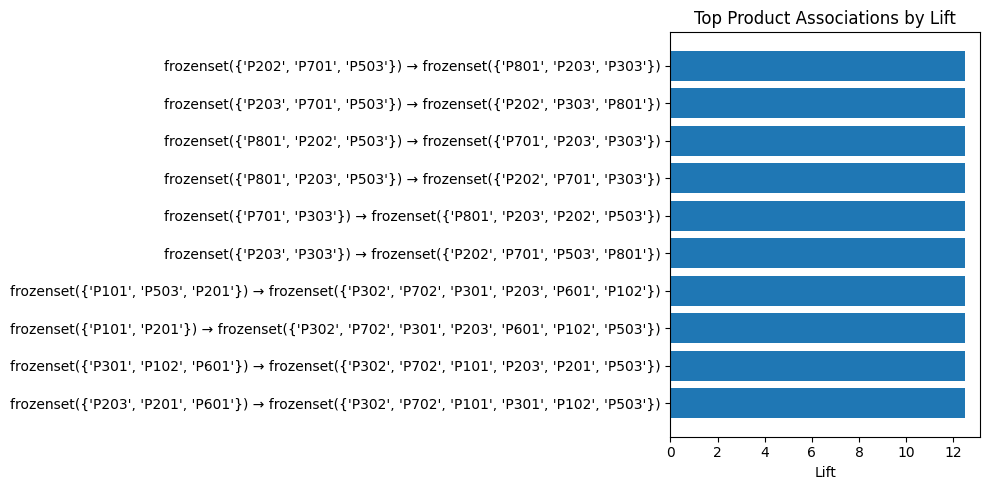

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [15]:
top = rules.head(10)

labels = top["antecedents"].astype(str)+" → "+top["consequents"].astype(str)

plt.figure(figsize=(10,5))

plt.barh(labels, top["lift"])

plt.title("Top Product Associations by Lift")
plt.xlabel("Lift")

plt.tight_layout()

plt.savefig(os.path.join(PROJECT_PATH,"outputs/charts/top_associations.png"))

plt.show()

In [16]:
from sklearn.neighbors import NearestNeighbors
import joblib

knn = NearestNeighbors(
    metric="cosine",
    algorithm="brute",
    n_neighbors=5
)

knn.fit(basket)

joblib.dump(
    knn,
    os.path.join(PROJECT_PATH,"models","knn_recommendation_model.pkl")
)

print("Model saved.")

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Model saved.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
import pandas as pd

# Function to recommend products for a customer
def recommend_products(customer_id, basket, knn, top_n=5):
    if customer_id not in basket.index:
        return []

    customer_vector = basket.loc[[customer_id]]
    distances, indices = knn.kneighbors(customer_vector)

    similar_customers = basket.iloc[indices[0][1:]].index

    purchased = set(basket.loc[customer_id][basket.loc[customer_id] == 1].index)

    recommendations = {}

    for sim in similar_customers:
        sim_products = basket.loc[sim][basket.loc[sim] == 1].index
        for product in sim_products:
            if product not in purchased:
                recommendations[product] = recommendations.get(product, 0) + 1

    return sorted(recommendations.items(), key=lambda x: x[1], reverse=True)[:top_n]

# Example
customer = basket.index[0]
recommend_products(customer, basket, knn)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

[('P302', 3), ('P301', 2), ('P702', 2), ('P203', 2), ('P103', 1)]

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [19]:
import os

total_customers = basket.shape[0]

# Calculate distances for all customers to get an overall average similarity
distances, _ = knn.kneighbors(basket)
avg_similarity = 1 - distances.mean()

metrics = f"""
KNN Recommendation Model Evaluation
-----------------------------------
Customers Analysed : {total_customers}
Nearest Neighbours : 5
Average Similarity Score : {avg_similarity:.3f}

Model successfully identifies customers with similar purchase behaviour.
"""

metrics_path = os.path.join(PROJECT_PATH, "outputs", "model_metrics.txt")

with open(metrics_path, "w") as f:
    f.write(metrics)

print(metrics)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag


KNN Recommendation Model Evaluation
-----------------------------------
Customers Analysed : 25
Nearest Neighbours : 5
Average Similarity Score : 0.688

Model successfully identifies customers with similar purchase behaviour.



/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [20]:
customer_pref = (
    df.groupby("Customer_ID")["Product_Category"]
      .agg(lambda x: x.mode()[0])
      .reset_index(name="Favorite_Category")
)

customer_pref.to_csv(
    os.path.join(PROJECT_PATH, "outputs", "customer_preferences.csv"),
    index=False
)

customer_pref.head()

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,Customer_ID,Favorite_Category
0,C001,Beauty
1,C002,Books
2,C003,Beauty
3,C004,Electronics
4,C005,Electronics


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
